<h1 style = color:green>Understand the dataset:</h1>

### Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal

import warnings
warnings.filterwarnings('ignore')

### Load the Dataset

In [2]:
df = pd.read_csv("311_Service_Requests_from_2010_to_Present.csv")
df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01/01/2016 12:55:15 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01/01/2016 01:26:57 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01/01/2016 04:51:03 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01/01/2016 07:43:13 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01/01/2016 03:24:42 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


In [3]:
df.shape

(364558, 53)

In [4]:
df.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot Name', 'Ferry 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364558 entries, 0 to 364557
Data columns (total 53 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Unique Key                      364558 non-null  int64  
 1   Created Date                    364558 non-null  object 
 2   Closed Date                     362177 non-null  object 
 3   Agency                          364558 non-null  object 
 4   Agency Name                     364558 non-null  object 
 5   Complaint Type                  364558 non-null  object 
 6   Descriptor                      358057 non-null  object 
 7   Location Type                   364425 non-null  object 
 8   Incident Zip                    361560 non-null  float64
 9   Incident Address                312859 non-null  object 
 10  Street Name                     312859 non-null  object 
 11  Cross Street 1                  307370 non-null  object 
 12  Cross Street 2  

### Find Missing Values

In [6]:
df.isnull().sum()

Unique Key                             0
Created Date                           0
Closed Date                         2381
Agency                                 0
Agency Name                            0
Complaint Type                         0
Descriptor                          6501
Location Type                        133
Incident Zip                        2998
Incident Address                   51699
Street Name                        51699
Cross Street 1                     57188
Cross Street 2                     57805
Intersection Street 1             313438
Intersection Street 2             314046
Address Type                        3252
City                                2997
Landmark                          364183
Facility Type                       2389
Status                                 0
Due Date                               3
Resolution Description                 0
Resolution Action Updated Date      2402
Community Board                        0
Borough         

#### Observation

- Dataset loaded successfully.
- It contains 53 columns.
- Several columns have missing values.
- Date columns are currently stored as object type.
- Data cleaning is required before analysis.

<h1 style = color:green>Perform Basic Exploratory Data Analysis:</h1>

### Plot Missing Values

In [7]:
missing_values = df.isnull().sum()
missing_values

Unique Key                             0
Created Date                           0
Closed Date                         2381
Agency                                 0
Agency Name                            0
Complaint Type                         0
Descriptor                          6501
Location Type                        133
Incident Zip                        2998
Incident Address                   51699
Street Name                        51699
Cross Street 1                     57188
Cross Street 2                     57805
Intersection Street 1             313438
Intersection Street 2             314046
Address Type                        3252
City                                2997
Landmark                          364183
Facility Type                       2389
Status                                 0
Due Date                               3
Resolution Description                 0
Resolution Action Updated Date      2402
Community Board                        0
Borough         

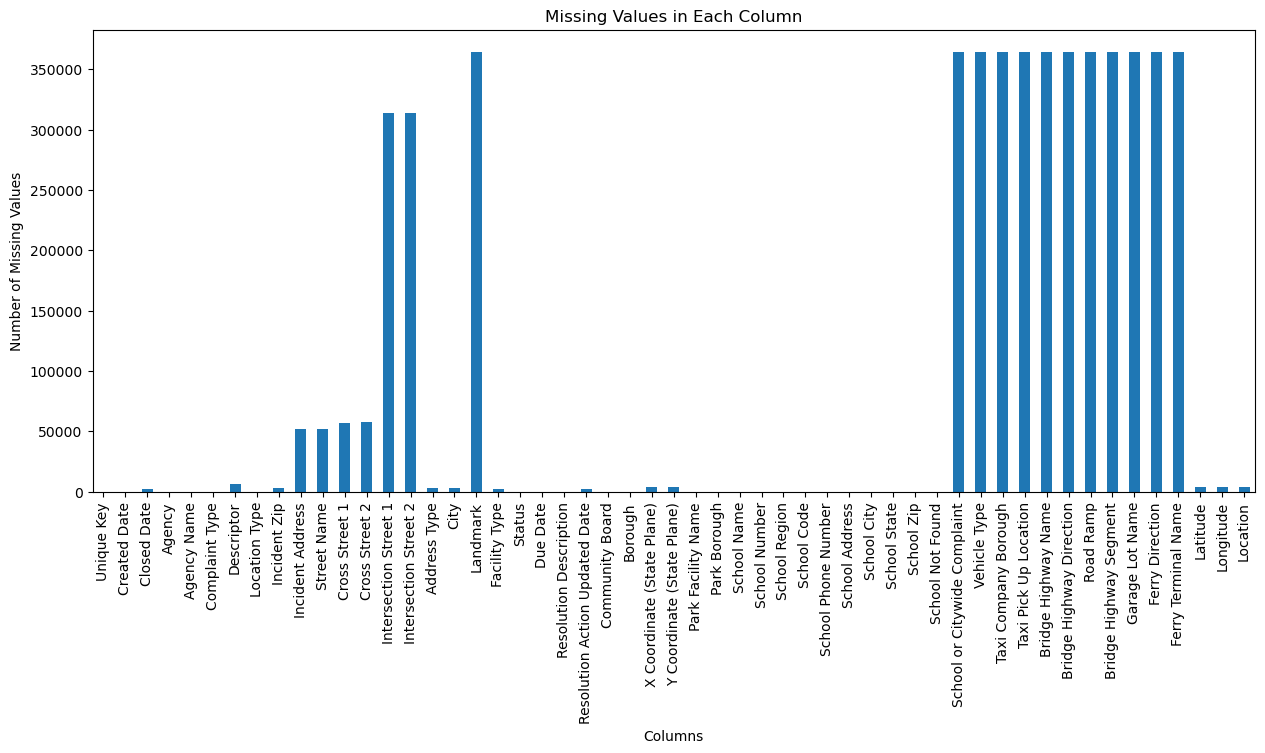

In [8]:
plt.figure(figsize=(15,6))

missing_values.plot(kind='bar')

plt.title("Missing Values in Each Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=90)

plt.show()

Observation:

• Several columns contain missing values.
• Some optional fields such as Landmark, Facility Type, School Name, etc., have a large number of missing values.
• Important columns like Created Date and Complaint Type should be checked carefully before further analysis.

### Remove Records with Missing Closed Date

In [9]:
df['Closed Date'].isnull().sum()

np.int64(2381)

In [10]:
df = df.dropna(subset=['Closed Date'])

In [11]:
df['Closed Date'].isnull().sum()

np.int64(0)

Rows with missing Closed Date were removed because the request closing time cannot be calculated without them.

### Convert Date Columns

In [12]:
df[['Created Date', 'Closed Date']].dtypes

Created Date    object
Closed Date     object
dtype: object

In [13]:
df['Created Date'] = pd.to_datetime(df['Created Date'])
df['Closed Date'] = pd.to_datetime(df['Closed Date'])

In [14]:
df[['Created Date', 'Closed Date']].dtypes

Created Date    datetime64[ns]
Closed Date     datetime64[ns]
dtype: object

### Remove Incorrect Timeline

In [15]:
invalid_records = df[df['Closed Date'] < df['Created Date']]
invalid_records

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location


In [16]:
len(invalid_records)

0

In [17]:
df = df[df['Closed Date'] >= df['Created Date']]

In [18]:
len(df[df['Closed Date'] < df['Created Date']])

0

### Calculate Request Closing Time

In [19]:
df['Request_Closing_Time'] = df['Closed Date'] - df['Created Date']

In [20]:
df[['Created Date', 'Closed Date', 'Request_Closing_Time']].head()

,Created Date,Closed Date,Request_Closing_Time
0,2015-12-31 23:59:45,2016-01-01 00:55:15,0 days 00:55:30
1,2015-12-31 23:59:44,2016-01-01 01:26:57,0 days 01:27:13
2,2015-12-31 23:59:29,2016-01-01 04:51:03,0 days 04:51:34
3,2015-12-31 23:57:46,2016-01-01 07:43:13,0 days 07:45:27
4,2015-12-31 23:56:58,2016-01-01 03:24:42,0 days 03:27:44


### Convert Closing Time to Seconds

In [21]:
df['Request_Closing_Time'] = df['Request_Closing_Time'].dt.total_seconds()

In [22]:
df[['Request_Closing_Time']].head()

,Request_Closing_Time
0,3330.0
1,5233.0
2,17494.0
3,27927.0
4,12464.0


### Descriptive Statistics

In [23]:
df['Request_Closing_Time'].describe()

count    3.621770e+05
mean     1.511330e+04
std      2.110255e+04
min      6.100000e+01
25%      4.533000e+03
50%      9.616000e+03
75%      1.887800e+04
max      2.134342e+06
Name: Request_Closing_Time, dtype: float64

In [24]:
df[['Complaint Type', 'City']].isnull().sum()

Complaint Type      0
City              674
dtype: int64

### Fill Missing City Values

In [25]:
df['City'] = df['City'].fillna("Unknown City")

In [26]:
df['City'].isnull().sum()

np.int64(0)

### Plot Complaints by City

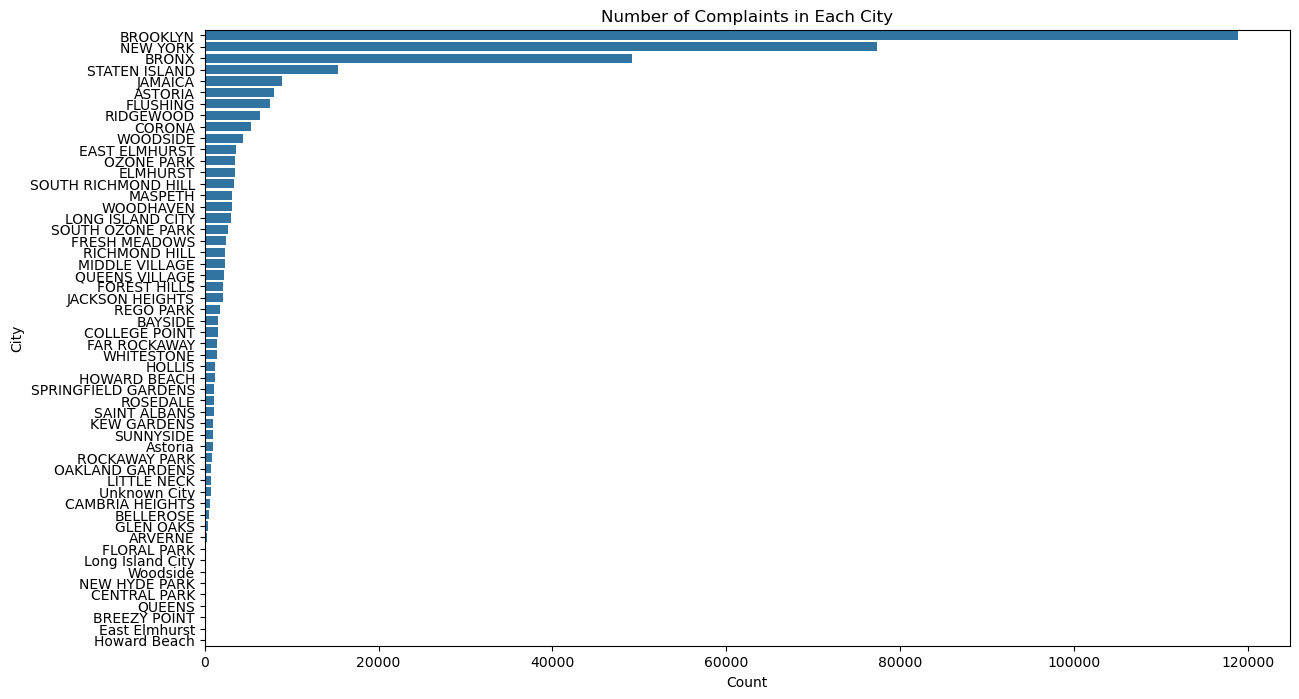

In [27]:
plt.figure(figsize=(14,8))

sns.countplot(
    data=df,
    y='City',
    order=df['City'].value_counts().index
)

plt.title("Number of Complaints in Each City")
plt.xlabel("Count")
plt.ylabel("City")

plt.show()

The graph shows the distribution of service requests across different cities. The city with the highest bar received the maximum number of complaints.

<h1 style = color:green>Find major types of complaints:</h1>

### Create a Dataset for Brooklyn

In [28]:
brooklyn = df[df['City'] == 'BROOKLYN']
brooklyn.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location,Request_Closing_Time
5,32306554,2015-12-31 23:56:30,2016-01-01 01:50:11,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,Street/Sidewalk,11215.0,260 21 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,40.660823,-73.992568,"(40.66082272389114, -73.99256786342693)",6821.0
9,32308391,2015-12-31 23:53:58,2016-01-01 01:17:40,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11219.0,1408 66 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,40.623793,-73.999539,"(40.623793065806524, -73.99953890121567)",5022.0
13,32305074,2015-12-31 23:47:58,2016-01-01 08:18:47,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,Street/Sidewalk,11208.0,38 COX PLACE,...,NaN,NaN,NaN,NaN,NaN,NaN,40.687511,-73.874505,"(40.68751060232221, -73.87450451131276)",30649.0
17,32310273,2015-12-31 23:44:52,2016-01-01 00:36:10,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,Club/Bar/Restaurant,11217.0,622 DEGRAW STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,40.679154,-73.983430,"(40.679154133157326, -73.98342992763081)",3078.0
18,32306617,2015-12-31 23:40:59,2016-01-01 02:37:28,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,Club/Bar/Restaurant,11234.0,2192 FLATBUSH AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,40.616550,-73.930202,"(40.61655032892211, -73.93020153359745)",10589.0


In [29]:
brooklyn.shape

(118849, 54)

### Scatter Plot

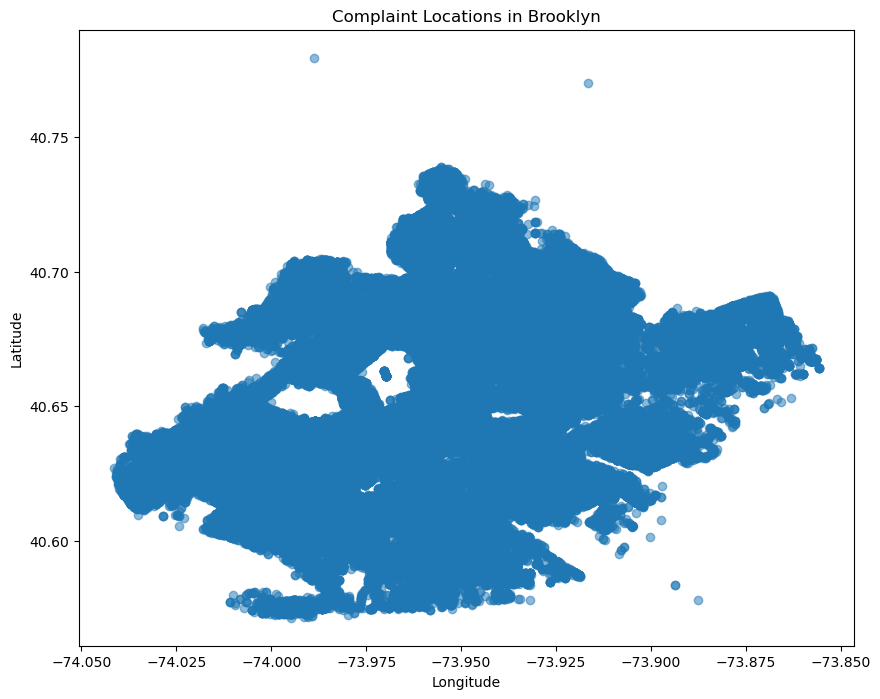

In [30]:
plt.figure(figsize=(10,8))

plt.scatter(
    brooklyn['Longitude'],
    brooklyn['Latitude'],
    alpha=0.5
)

plt.title("Complaint Locations in Brooklyn")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

The scatter plot shows the geographical distribution of complaints in Brooklyn.

### Hexbin Plot

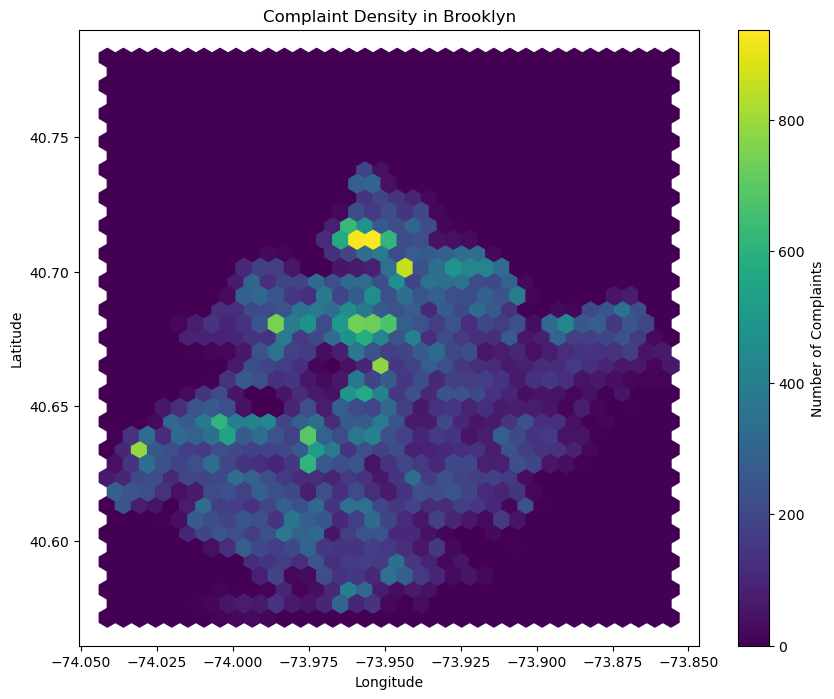

In [31]:
plt.figure(figsize=(10,8))

plt.hexbin(
    brooklyn['Longitude'],
    brooklyn['Latitude'],
    gridsize=35,
    cmap='viridis'
)

plt.colorbar(label='Number of Complaints')

plt.title("Complaint Density in Brooklyn")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

Darker hexagons represent areas where complaints are highly concentrated.

### Complaint Type Distribution

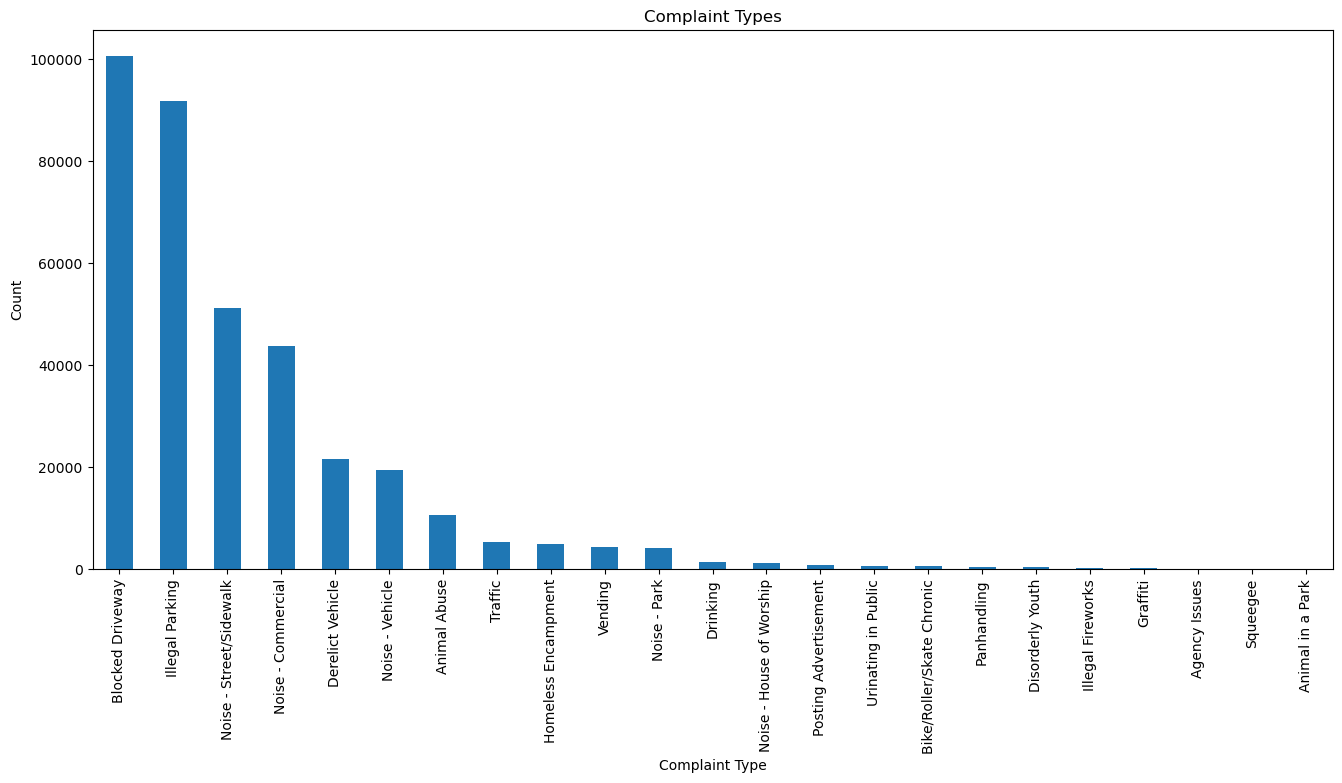

In [32]:
plt.figure(figsize=(16,7))

df['Complaint Type'].value_counts().plot(kind='bar')

plt.title("Complaint Types")
plt.xlabel("Complaint Type")
plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

### Complaint Frequency in New York City

In [33]:
new_york = df[df['City'] == 'NEW YORK']

In [34]:
new_york['Complaint Type'].value_counts()

Complaint Type
Noise - Street/Sidewalk      22245
Noise - Commercial           18686
Illegal Parking              14549
Noise - Vehicle               6294
Homeless Encampment           3060
Blocked Driveway              2705
Vending                       2638
Animal Abuse                  1941
Traffic                       1769
Noise - Park                  1243
Derelict Vehicle               695
Drinking                       321
Urinating in Public            264
Bike/Roller/Skate Chronic      254
Noise - House of Worship       222
Panhandling                    206
Disorderly Youth                81
Posting Advertisement           49
Illegal Fireworks               38
Graffiti                        25
Squeegee                         4
Name: count, dtype: int64

### Top 10 Complaint Types

In [35]:
top10 = df['Complaint Type'].value_counts().head(10)
top10

Complaint Type
Blocked Driveway           100624
Illegal Parking             91716
Noise - Street/Sidewalk     51139
Noise - Commercial          43751
Derelict Vehicle            21518
Noise - Vehicle             19301
Animal Abuse                10530
Traffic                      5196
Homeless Encampment          4879
Vending                      4185
Name: count, dtype: int64

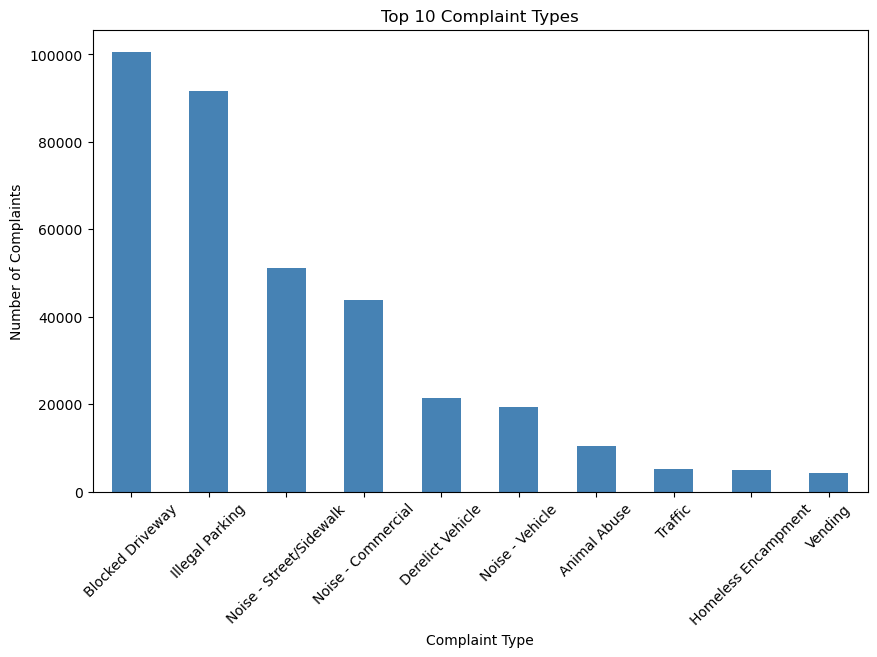

In [36]:
plt.figure(figsize=(10,6))

top10.plot(kind='bar', color='steelblue')

plt.title("Top 10 Complaint Types")
plt.xlabel("Complaint Type")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=45)

plt.show()

### Complaint Types Across Cities

In [37]:
city_complaints = pd.crosstab(
    df['City'],
    df['Complaint Type']
)

city_complaints

Complaint Type,Agency Issues,Animal Abuse,Animal in a Park,Bike/Roller/Skate Chronic,Blocked Driveway,Derelict Vehicle,Disorderly Youth,Drinking,Graffiti,Homeless Encampment,...,Noise - House of Worship,Noise - Park,Noise - Street/Sidewalk,Noise - Vehicle,Panhandling,Posting Advertisement,Squeegee,Traffic,Urinating in Public,Vending
City,,,,,,,,,,,,,,,,,,,,,
ARVERNE,0,46,0,0,50,32,2,1,1,4,...,14,2,29,10,1,0,0,1,1,1
ASTORIA,0,170,0,16,3436,426,5,43,4,32,...,21,64,409,236,2,3,0,60,10,57
Astoria,0,0,0,0,159,14,0,0,0,0,...,0,0,145,0,0,0,0,0,0,0
BAYSIDE,0,53,0,0,514,231,2,1,3,2,...,3,4,17,24,0,0,0,9,0,2
BELLEROSE,0,15,0,1,138,120,2,1,0,1,...,1,1,13,11,1,1,0,9,1,0
BREEZY POINT,0,2,0,0,3,3,0,1,0,0,...,0,0,1,1,0,0,0,0,0,0
BRONX,0,1971,0,22,17062,2402,66,206,15,275,...,90,548,9144,3556,20,18,0,427,54,433
BROOKLYN,0,3191,0,124,36445,6257,79,291,60,948,...,389,1575,13982,5965,49,58,0,1258,155,575
CAMBRIA HEIGHTS,0,15,0,0,177,148,0,0,0,6,...,2,0,29,100,0,0,0,7,0,0


### Create df_new

The project specifically asks for a DataFrame where:

- Rows = Complaint Types
- Columns = Cities

In [38]:
df_new = pd.crosstab(
    df['Complaint Type'],
    df['City']
)

df_new.head()

City,ARVERNE,ASTORIA,Astoria,BAYSIDE,BELLEROSE,BREEZY POINT,BRONX,BROOKLYN,CAMBRIA HEIGHTS,CENTRAL PARK,...,SOUTH OZONE PARK,SOUTH RICHMOND HILL,SPRINGFIELD GARDENS,STATEN ISLAND,SUNNYSIDE,Unknown City,WHITESTONE,WOODHAVEN,WOODSIDE,Woodside
Complaint Type,,,,,,,,,,,,,,,,,,,,,
Agency Issues,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,8,0,0,0,0
Animal Abuse,46,170,0,53,15,2,1971,3191,15,0,...,74,40,42,786,40,1,43,57,111,0
Animal in a Park,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bike/Roller/Skate Chronic,0,16,0,0,1,0,22,124,0,0,...,1,1,0,10,2,2,4,2,5,0
Blocked Driveway,50,3436,159,514,138,3,17062,36445,177,0,...,1202,1946,330,2845,278,86,279,1363,2038,27


In [39]:
df_new.shape

(23, 54)

### Save the Cleaned Dataset 

In [40]:
df.to_csv("cleaned_311_requests.csv", index=False)

### Observations

- Complaint locations are unevenly distributed across Brooklyn.
- Some areas have a higher density of complaints than others.
- The bar chart highlights the most common complaint categories.
- The Top 10 complaint types account for a significant share of all service requests.
- The crosstab provides a city-wise breakdown of complaint categories.
- The `df_new` DataFrame will be used in the next step for comparing complaint types across cities.

<h1 style = color:green>Visualize the major types of complaints in each city</h1>

### Stacked Bar Chart (Complaint Types by City)

<Figure size 1800x800 with 0 Axes>

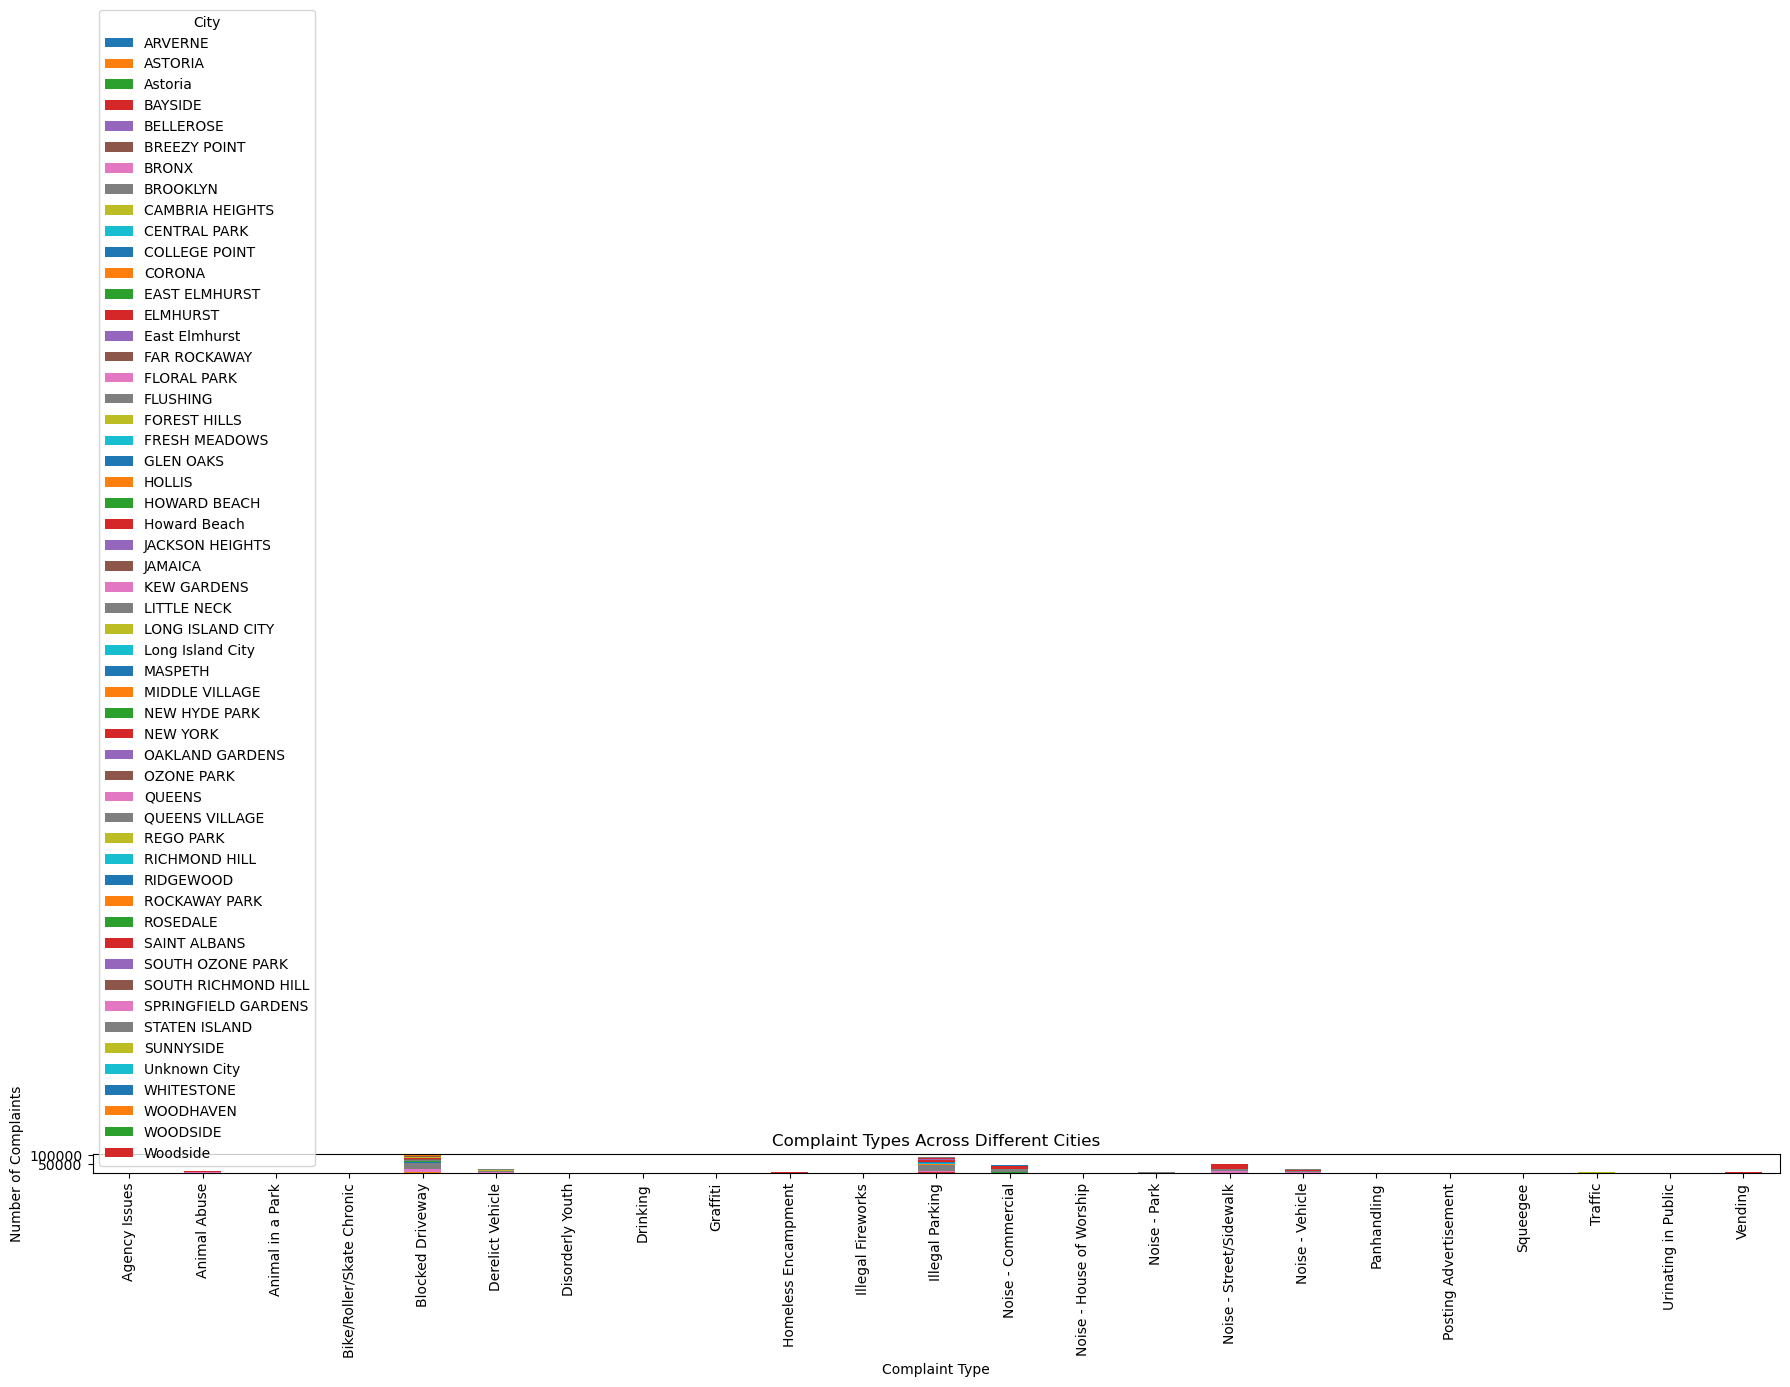

In [41]:
plt.figure(figsize=(18,8))

df_new.plot(
    kind='bar',
    stacked=True,
    figsize=(18,8)
)

plt.title("Complaint Types Across Different Cities")
plt.xlabel("Complaint Type")
plt.ylabel("Number of Complaints")

plt.tight_layout()
plt.show()

The stacked bar chart compares complaint types across different cities. Each colour represents a different city.

### Calculate Average Request Closing Time

In [42]:
avg_closing_time = df.groupby('Complaint Type')['Request_Closing_Time'].mean()

avg_closing_time.sort_values()

Complaint Type
Posting Advertisement        7.286256e+03
Illegal Fireworks            1.011348e+04
Noise - Commercial           1.108576e+04
Noise - House of Worship     1.139109e+04
Noise - Park                 1.222606e+04
Noise - Street/Sidewalk      1.223130e+04
Traffic                      1.230912e+04
Disorderly Youth             1.236375e+04
Noise - Vehicle              1.256180e+04
Urinating in Public          1.295929e+04
Bike/Roller/Skate Chronic    1.312369e+04
Drinking                     1.382130e+04
Vending                      1.436628e+04
Squeegee                     1.456025e+04
Homeless Encampment          1.545138e+04
Illegal Parking              1.565044e+04
Panhandling                  1.585355e+04
Blocked Driveway             1.623252e+04
Animal Abuse                 1.803256e+04
Agency Issues                1.828912e+04
Graffiti                     2.327634e+04
Derelict Vehicle             2.535960e+04
Animal in a Park             1.212634e+06
Name: Request_Closi

### Plot Average Response Time

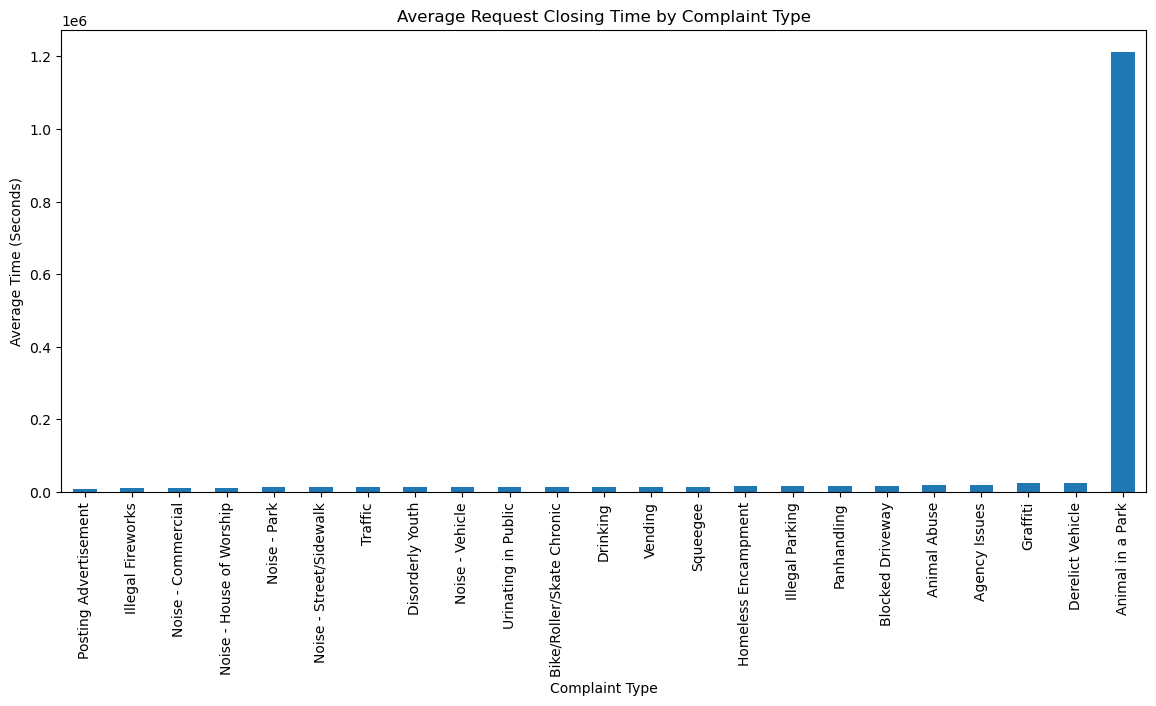

In [43]:
plt.figure(figsize=(14,6))

avg_closing_time.sort_values().plot(kind='bar')

plt.title("Average Request Closing Time by Complaint Type")
plt.xlabel("Complaint Type")
plt.ylabel("Average Time (Seconds)")

plt.xticks(rotation=90)

plt.show()

Some complaint types require significantly more time to resolve than others.

### Statistical Analysis (Kruskal-Wallis H Test)

The project specifically asks for a Kruskal-Wallis H Test.

- Hypothesis

Null Hypothesis (H₀):

The average response time is the same for all complaint types.

- Alternative Hypothesis (H₁):

At least one complaint type has a different average response time.

### Prepare the Data

In [44]:
groups = []

for complaint in df['Complaint Type'].dropna().unique():
    group = df[df['Complaint Type'] == complaint]['Request_Closing_Time']
    groups.append(group)

### Run the Test

In [45]:
from scipy.stats import kruskal

statistic, p_value = kruskal(*groups)

print("Statistic:", statistic)
print("P-value:", p_value)

Statistic: 11988.269402358468
P-value: 0.0


### Interpret the Result

In [46]:
if p_value > 0.05:
    print("Fail to Reject H0")
    print("All sample distributions are equal.")
else:
    print("Reject H0")
    print("One or more sample distributions are not equal.")

Reject H0
One or more sample distributions are not equal.


### Observation

• Kruskal-Wallis H Test was performed.
• Null Hypothesis: All complaint types have similar response times.
• Alternative Hypothesis: At least one complaint type has a different response time.
• The decision was made based on the p-value.

## Final Observations

1. The dataset contained missing values, which were handled appropriately.
2. Invalid records with incorrect timelines were removed.
3. Request Closing Time was calculated in seconds.
4. Complaint frequency varied significantly across cities.
5. Brooklyn showed clusters of complaints in specific areas.
6. Noise-related complaints were among the most frequent.
7. Average response time differed across complaint categories.
8. The Kruskal-Wallis H Test indicated whether these differences were statistically significant.
9. Visualisations helped identify complaint patterns across cities.
10. The cleaned dataset is suitable for further predictive analysis.
